In [ ]:
import marimo as mo

# ElectionIndustryBeta P&L Attribution

This marimo notebook mirrors `pl_attribution.ipynb`. It attributes the latest
saved backtest output across long/short exposure, ticker contribution versus
beta-weighted allocation, and realized signal decay.

The notebook reads the ObjectStore CSVs written by `models/logger.py`; it does
not modify algorithm behavior.

In [ ]:
from io import StringIO
from pathlib import Path
import sys
import zipfile

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("dark_background")
mpl.rcParams.update(
    {
        "figure.facecolor": "#0d1117",
        "axes.facecolor": "#161b22",
        "axes.edgecolor": "#30363d",
        "axes.labelcolor": "#c9d1d9",
        "axes.grid": True,
        "grid.color": "#21262d",
        "grid.alpha": 0.6,
        "text.color": "#c9d1d9",
        "xtick.color": "#8b949e",
        "ytick.color": "#8b949e",
        "font.family": "sans-serif",
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "figure.dpi": 150,
        "savefig.facecolor": "#0d1117",
        "savefig.edgecolor": "#0d1117",
    }
)

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for path in [cwd, *cwd.parents]:
        if (path / "main.py").exists() and (path / "domain" / "config.py").exists():
            return path
        nested = path / "ElectionIndustryBeta"
        if (nested / "main.py").exists() and (nested / "domain" / "config.py").exists():
            return nested
        workspace_nested = path / "MyProjects" / "ElectionIndustryBeta"
        if (workspace_nested / "main.py").exists() and (
            workspace_nested / "domain" / "config.py"
        ).exists():
            return workspace_nested
    raise FileNotFoundError(
        "Could not locate ElectionIndustryBeta project root from the current working directory"
    )

PROJECT_ROOT = find_project_root()
MYPROJECTS_ROOT = PROJECT_ROOT.parent
WORKSPACE_ROOT = MYPROJECTS_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from domain.config import OBJECTSTORE_NAMESPACE, UNIVERSE

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:,.4f}".format)

In [ ]:
mo.callout(
    mo.md(
        """
        Local ObjectStore files are read first from `MyProjects/storage/electionbeta/`.
        If those files are unavailable inside a LEAN research container, the notebook
        falls back to `QuantBook().ObjectStore`.
        """
    ),
    kind="info",
)

<marimo-callout-output data-html='"\u003cspan class=\"markdown prose dark:prose-invert contents\"\u003e\u003cspan class=\"paragraph\"\u003eLocal ObjectStore files are read first from \u003ccode\u003eMyProjects/storage/electionbeta/\u003c/code\u003e.\nIf those files are unavailable inside a LEAN research container, the notebook\nfalls back to \u003ccode\u003eQuantBook().ObjectStore\u003c/code\u003e.\u003c/span\u003e\u003c/span\u003e"' data-kind='"info"'>

In [ ]:
def get_quantbook():
    if "qb" in globals():
        return globals()["qb"]
    try:
        from QuantConnect.Research import QuantBook

        globals()["qb"] = QuantBook()
        return globals()["qb"]
    except Exception:
        return None

def read_objectstore_csv(filename: str) -> pd.DataFrame:
    local_path = MYPROJECTS_ROOT / "storage" / OBJECTSTORE_NAMESPACE / filename
    if local_path.exists():
        return pd.read_csv(local_path, parse_dates=["date"])

    book = get_quantbook()
    key = f"{OBJECTSTORE_NAMESPACE}/{filename}"
    if book is not None:
        blob = book.ObjectStore.Read(key)
        if blob:
            return pd.read_csv(StringIO(blob), parse_dates=["date"])

    raise FileNotFoundError(
        f"Could not read {filename} locally or from ObjectStore key {key}"
    )

## Load Backtest Logs

These are the three CSVs emitted by `PortfolioLogger` at `OnEndOfAlgorithm`.

In [ ]:
snapshots = read_objectstore_csv("daily_snapshots.csv").sort_values("date")
positions = read_objectstore_csv("positions.csv").sort_values(["date", "symbol"])
trades = read_objectstore_csv("trades.csv").sort_values(["date", "symbol"])

for frame in (snapshots, positions, trades):
    frame["date"] = pd.to_datetime(frame["date"]).dt.normalize()

positions["symbol"] = positions["symbol"].astype(str)
positions["side"] = np.where(positions["target_weight"] > 0, "Long", "Short")
positions["abs_target_weight"] = positions["target_weight"].abs()

In [ ]:
mo.vstack(
    [
        mo.md(
            f"""
            **Loaded rows**

            - Snapshots: `{len(snapshots):,}`
            - Positions: `{len(positions):,}`
            - Trades: `{len(trades):,}`
            """
        ),
        mo.ui.dataframe(snapshots.head()),
        mo.ui.dataframe(positions.head()),
        mo.ui.dataframe(trades.head()),
    ]
)

Loaded rows 
 
 Snapshots: 165 
 Positions: 953 
 Trades: 814 
 <marimo-dataframe data-initial-value='{"transforms":[]}' data-label='null' data-columns='[["date","datetime","datetime64[us]"],["nav","number","float64"],["gross_exposure","number","float64"],["n_long","integer","int64"],["n_short","integer","int64"],["p_trump","number","float64"],["delta_p","number","float64"]]' data-dataframe-name='"df"' data-total='5' data-size-bytes='621' data-page-size='5' data-show-download='true' data-download-json-ensure-ascii='true' data-lazy='false'> <marimo-dataframe data-initial-value='{"transforms":[]}' data-label='null' data-columns='[["date","datetime","datetime64[us]"],["symbol","string","str"],["quantity","number","float64"],["price","number","float64"],["target_weight","number","float64"],["side","string","str"],["abs_target_weight","number","float64"]]' data-dataframe-name='"df"' data-total='5' data-size-bytes='824' data-page-size='5' data-show-download='true' data-download-json-ensure-ascii='true' data-lazy='false'> <marimo-dataframe data-initial-value='{"transforms":[]}' data-label='null' data-columns='[["date","datetime","datetime64[us]"],["symbol","string","str"],["action","string","str"],["quantity","number","float64"],["price","number","float64"]]' data-dataframe-name='"df"' data-total='5' data-size-bytes='511' data-page-size='5' data-show-download='true' data-download-json-ensure-ascii='true' data-lazy='false'>

## Price Panel

Daily LEAN files are used only as a fallback for positions that disappear from
the logged position table on the next rebalance. The attribution prefers logged
position prices and next-rebalance trade fill prices because those reconcile to
the algorithm's observed NAV path.

In [ ]:
def read_lean_daily_close(ticker: str) -> pd.Series | None:
    zip_path = (
        MYPROJECTS_ROOT
        / "data"
        / "equity"
        / "usa"
        / "daily"
        / f"{ticker.lower()}.zip"
    )
    if not zip_path.exists():
        return None

    with zipfile.ZipFile(zip_path) as archive:
        member = archive.namelist()[0]
        raw = pd.read_csv(
            archive.open(member),
            header=None,
            names=["date", "open", "high", "low", "close", "volume"],
        )

    dates = pd.to_datetime(raw["date"].astype(str).str.slice(0, 8), format="%Y%m%d")
    closes = raw["close"].astype(float) / 10000.0
    return pd.Series(closes.to_numpy(), index=dates, name=ticker).sort_index()

close_prices = pd.DataFrame(
    {
        ticker: series
        for ticker in UNIVERSE
        if (series := read_lean_daily_close(ticker)) is not None
    }
).sort_index()

if close_prices.empty:
    close_prices = positions.pivot_table(
        index="date", columns="symbol", values="price", aggfunc="last"
    ).sort_index()

# Daily-resolution rebalance after the open uses the prior daily bar.
asof_prices = close_prices.shift(1)

In [ ]:
if close_prices.empty:
    _output = mo.callout(mo.md("No local daily price panel was available."), kind="warn")
else:
    _start = snapshots["date"].min()
    _preview = close_prices.loc[_start : _start + snapshots["date"].diff().median()].head()
    _output = mo.vstack(
        [
            mo.md(
                f"Price panel: `{close_prices.shape[0]:,}` dates x `{close_prices.shape[1]:,}` tickers"
            ),
            mo.ui.dataframe(_preview),
        ]
    )
_output

Price panel: 241 dates x 19 tickers <marimo-dataframe data-initial-value='{"transforms":[]}' data-label='null' data-columns='[["XLE","number","float64"],["XLF","number","float64"],["XLV","number","float64"],["XLI","number","float64"],["XLK","number","float64"],["XLP","number","float64"],["XLY","number","float64"],["XLU","number","float64"],["XLB","number","float64"],["XLRE","number","float64"],["XLC","number","float64"],["XOP","number","float64"],["ITA","number","float64"],["KBE","number","float64"],["IBB","number","float64"],["ICLN","number","float64"],["TAN","number","float64"],["GDX","number","float64"],["ITB","number","float64"]]' data-dataframe-name='"_cell_Kclp_preview"' data-total='1' data-size-bytes='274' data-page-size='5' data-show-download='true' data-download-json-ensure-ascii='true' data-lazy='false'>

## One-Period Position Attribution

Each row attributes mark-to-market movement from one rebalance to the next.
`pnl_qty` uses logged quantity and price. `pnl_weight` uses the logged
beta-weighted target allocation, NAV, and the same forward return.

In [ ]:
rebalance_dates = list(pd.to_datetime(snapshots["date"]).sort_values())
next_rebalance = {
    date: rebalance_dates[i + 1] for i, date in enumerate(rebalance_dates[:-1])
}

attr = positions.merge(
    snapshots[["date", "nav", "p_trump", "delta_p"]],
    on="date",
    how="left",
)
attr["next_date"] = attr["date"].map(next_rebalance)
attr = attr.dropna(subset=["next_date"]).copy()
attr["next_date"] = pd.to_datetime(attr["next_date"]).dt.normalize()

logged_next_prices = positions[["date", "symbol", "price"]].rename(
    columns={"date": "next_date", "price": "next_logged_price"}
)
attr = attr.merge(logged_next_prices, on=["next_date", "symbol"], how="left")

trade_next_prices = trades.copy()
trade_next_prices["abs_quantity"] = trade_next_prices["quantity"].abs()
trade_next_prices["weighted_price"] = (
    trade_next_prices["price"] * trade_next_prices["abs_quantity"]
)
trade_next_prices = trade_next_prices.groupby(["date", "symbol"], as_index=False).agg(
    weighted_price=("weighted_price", "sum"),
    abs_quantity=("abs_quantity", "sum"),
    last_price=("price", "last"),
)
trade_next_prices["next_trade_price"] = np.where(
    trade_next_prices["abs_quantity"] > 0,
    trade_next_prices["weighted_price"] / trade_next_prices["abs_quantity"],
    trade_next_prices["last_price"],
)
trade_next_prices = trade_next_prices[["date", "symbol", "next_trade_price"]].rename(
    columns={"date": "next_date"}
)
attr = attr.merge(trade_next_prices, on=["next_date", "symbol"], how="left")

fallback_next_prices = asof_prices.stack().rename("next_fallback_price").reset_index()
fallback_next_prices.columns = ["next_date", "symbol", "next_fallback_price"]
attr = attr.merge(fallback_next_prices, on=["next_date", "symbol"], how="left")
attr["next_price"] = (
    attr["next_logged_price"]
    .combine_first(attr["next_trade_price"])
    .combine_first(attr["next_fallback_price"])
)

attr["return_1d"] = attr["next_price"] / attr["price"] - 1.0
attr["pnl_qty"] = attr["quantity"] * (attr["next_price"] - attr["price"])
attr["pnl_weight"] = attr["nav"] * attr["target_weight"] * attr["return_1d"]
attr["signed_return"] = np.sign(attr["target_weight"]) * attr["return_1d"]
attr = attr.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["return_1d", "pnl_qty"]
)

nav_recon = snapshots[["date", "nav"]].copy()
nav_recon["next_nav"] = nav_recon["nav"].shift(-1)
nav_recon["nav_delta"] = nav_recon["next_nav"] - nav_recon["nav"]
daily_attr = attr.groupby("date", as_index=False).agg(
    attributed_pnl=("pnl_qty", "sum"),
    beta_weight_model_pnl=("pnl_weight", "sum"),
)
nav_recon = nav_recon.merge(daily_attr, on="date", how="left")
nav_recon["residual"] = nav_recon["nav_delta"] - nav_recon["attributed_pnl"]

price_diagnostics = positions.groupby("symbol").agg(
    days_logged=("date", "nunique"),
    unique_logged_prices=("price", "nunique"),
    first_date=("date", "min"),
    last_date=("date", "max"),
)
price_diagnostics["stale_price_flag"] = price_diagnostics["unique_logged_prices"] <= 1
price_diagnostics = price_diagnostics.sort_values(
    ["stale_price_flag", "unique_logged_prices"], ascending=[False, True]
)

In [ ]:
_stale_count = int(price_diagnostics["stale_price_flag"].sum())
_diagnostic = (
    mo.callout(
        mo.md(
            f"""
            **Logged-price diagnostic:** `{_stale_count}` tickers have only one
            unique logged price in this local backtest. The realized attribution
            still reconciles closely to NAV because it uses next fill prices when
            positions exit, but ticker-level interpretation should account for this.
            """
        ),
        kind="warn",
    )
    if _stale_count
    else mo.callout(mo.md("Logged position prices vary by ticker as expected."), kind="success")
)

mo.vstack(
    [
        mo.ui.dataframe(attr.head()),
        mo.ui.dataframe(
            nav_recon[
                ["nav_delta", "attributed_pnl", "beta_weight_model_pnl", "residual"]
            ].describe()
        ),
        _diagnostic,
        mo.ui.dataframe(price_diagnostics),
    ]
)

<marimo-dataframe data-initial-value='{"transforms":[]}' data-label='null' data-columns='[["date","datetime","datetime64[us]"],["symbol","string","str"],["quantity","number","float64"],["price","number","float64"],["target_weight","number","float64"],["side","string","str"],["abs_target_weight","number","float64"],["nav","number","float64"],["p_trump","number","float64"],["delta_p","number","float64"],["next_date","datetime","datetime64[us]"],["next_logged_price","number","float64"],["next_trade_price","number","float64"],["next_fallback_price","number","float64"],["next_price","number","float64"],["return_1d","number","float64"],["pnl_qty","number","float64"],["pnl_weight","number","float64"],["signed_return","number","float64"]]' data-dataframe-name='"df"' data-total='5' data-size-bytes='2169' data-page-size='5' data-show-download='true' data-download-json-ensure-ascii='true' data-lazy='false'> <marimo-dataframe data-initial-value='{"transforms":[]}' data-label='null' data-columns='[["nav_delta","number","float64"],["attributed_pnl","number","float64"],["beta_weight_model_pnl","number","float64"],["residual","number","float64"]]' data-dataframe-name='"df"' data-total='8' data-size-bytes='920' data-page-size='5' data-show-download='true' data-download-json-ensure-ascii='true' data-lazy='false'> <marimo-callout-output data-html='"\u003cspan class=\"markdown prose dark:prose-invert contents\"\u003e\u003cspan class=\"paragraph\"\u003e\u003cstrong\u003eLogged-price diagnostic:\u003c/strong\u003e \u003ccode\u003e16\u003c/code\u003e tickers have only one\nunique logged price in this local backtest. The realized attribution\nstill reconciles closely to NAV because it uses next fill prices when\npositions exit, but ticker-level interpretation should account for this.\u003c/span\u003e\u003c/span\u003e"' data-kind='"warn"'> <marimo-dataframe data-initial-value='{"transforms":[]}' data-label='null' data-columns='[["days_logged","integer","int64"],["unique_logged_prices","integer","int64"],["first_date","datetime","datetime64[us]"],["last_date","datetime","datetime64[us]"],["stale_price_flag","boolean","bool"]]' data-dataframe-name='"price_diagnostics"' data-total='19' data-size-bytes='3053' data-page-size='5' data-show-download='true' data-download-json-ensure-ascii='true' data-lazy='false'>

## Long / Short

In [ ]:
long_short = attr.groupby("side").agg(
    pnl=("pnl_qty", "sum"),
    beta_weight_model_pnl=("pnl_weight", "sum"),
    gross_weight_days=("abs_target_weight", "sum"),
    avg_abs_weight=("abs_target_weight", "mean"),
    observations=("symbol", "size"),
    hit_rate=("pnl_qty", lambda x: (x > 0).mean()),
)
long_short["pnl_per_gross_weight_day"] = (
    long_short["pnl"] / long_short["gross_weight_days"]
)
long_short = long_short.sort_values("pnl")
daily_side = (
    attr.pivot_table(index="next_date", columns="side", values="pnl_qty", aggfunc="sum")
    .fillna(0.0)
    .sort_index()
)

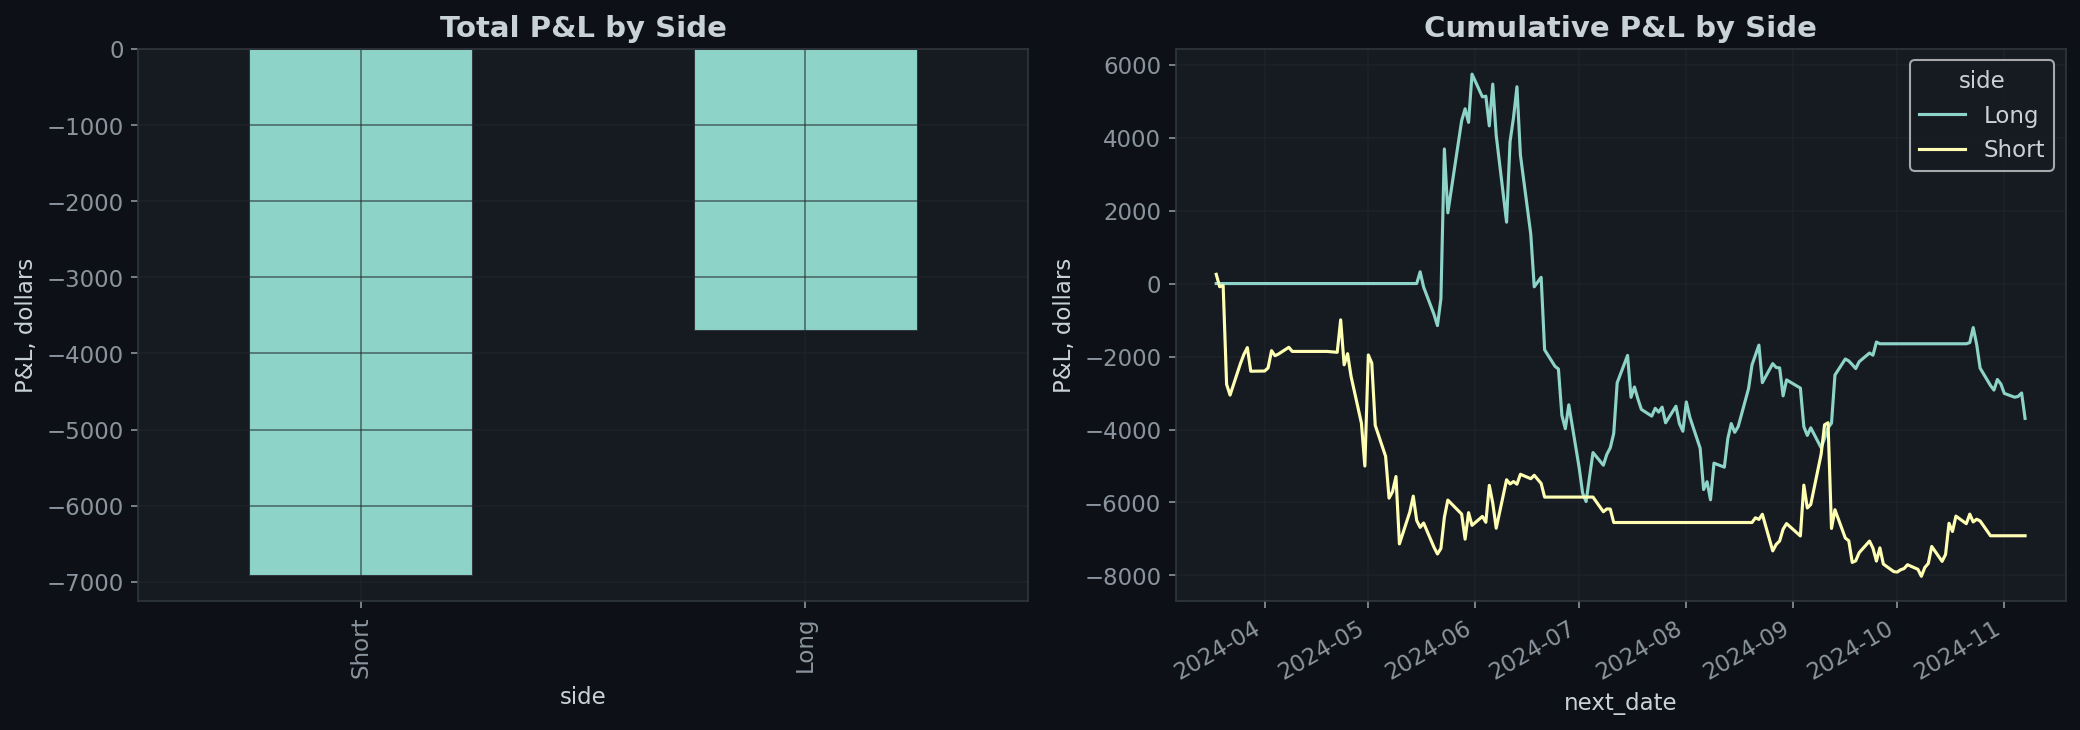

,pnl,beta_weight_model_pnl,gross_weight_days,avg_abs_weight,observations,hit_rate,pnl_per_gross_weight_day
side,,,,,,,
Short,"-6,911.6100","-6,926.4512",88.0628,0.1649,534,0.1667,-78.4850
Long,"-3,695.7000","-3,724.2997",75.9372,0.1839,413,0.1792,-48.6678


In [ ]:
if long_short.empty:
    _output = mo.callout(
        mo.md("No long/short attribution rows are available."), kind="warn"
    )
else:
    _fig, _axes = plt.subplots(1, 2, figsize=(14, 5))
    long_short["pnl"].sort_values().plot(
        kind="bar",
        ax=_axes[0],
        title="Total P&L by Side",
        edgecolor="#30363d",
        linewidth=0.5,
    )
    _axes[0].set_ylabel("P&L, dollars")
    daily_side.cumsum().plot(ax=_axes[1], title="Cumulative P&L by Side")
    _axes[1].set_ylabel("P&L, dollars")
    plt.tight_layout()
    plt.show()

    _output = mo.ui.dataframe(long_short)
_output

## Ticker P&L Versus Beta Weighting

`target_weight` is the actual beta-weighted allocation emitted by the
algorithm. The equal-selected counterfactual keeps the same selected tickers
and signs each day, but allocates the day's gross exposure equally across
selected names.

In [ ]:
ticker_base = attr.copy()
selected_count = ticker_base.groupby("date")["symbol"].transform("count")
ticker_base["equal_selected_weight"] = (
    np.sign(ticker_base["target_weight"]) / selected_count
)
ticker_base["equal_selected_pnl"] = (
    ticker_base["nav"] * ticker_base["equal_selected_weight"] * ticker_base["return_1d"]
)
ticker_base["weighting_effect"] = (
    ticker_base["pnl_weight"] - ticker_base["equal_selected_pnl"]
)

ticker_attr = ticker_base.groupby("symbol").agg(
    actual_pnl=("pnl_qty", "sum"),
    beta_weight_pnl=("pnl_weight", "sum"),
    equal_selected_pnl=("equal_selected_pnl", "sum"),
    weighting_effect=("weighting_effect", "sum"),
    gross_weight_days=("abs_target_weight", "sum"),
    avg_target_weight=("target_weight", "mean"),
    avg_abs_weight=("abs_target_weight", "mean"),
    days_selected=("date", "nunique"),
    hit_rate=("pnl_qty", lambda x: (x > 0).mean()),
)
ticker_attr["actual_pnl_per_gross_weight_day"] = (
    ticker_attr["actual_pnl"] / ticker_attr["gross_weight_days"]
)
ticker_attr = ticker_attr.sort_values("actual_pnl")

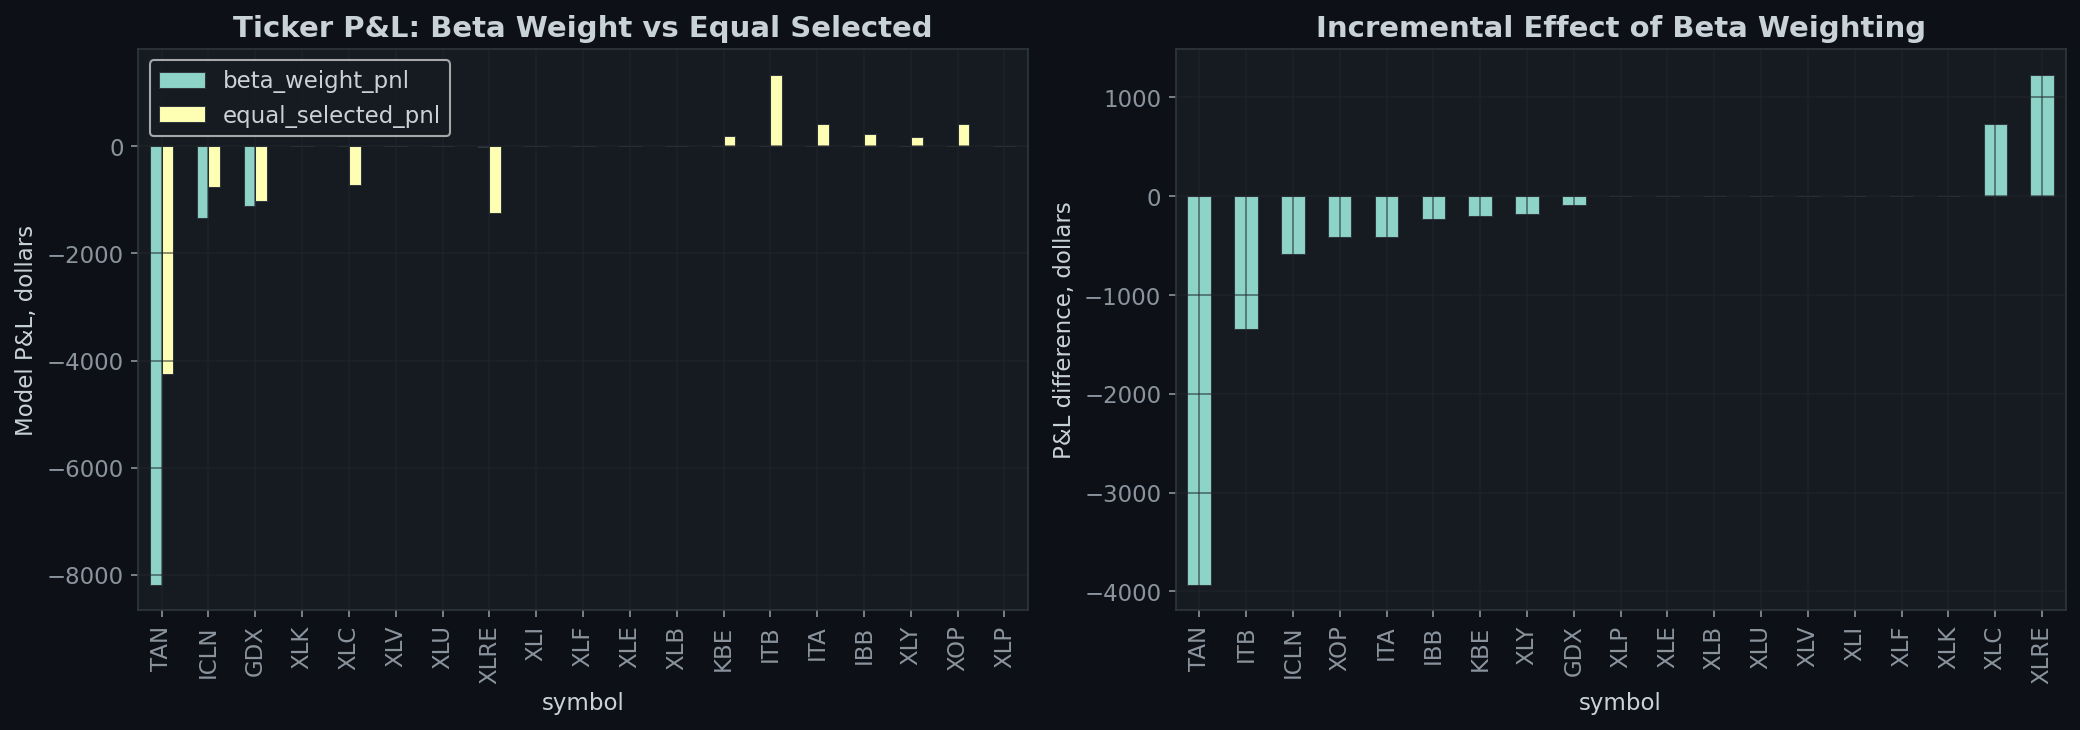

,actual_pnl,beta_weight_pnl,equal_selected_pnl,weighting_effect,gross_weight_days,avg_target_weight,avg_abs_weight,days_selected,hit_rate,actual_pnl_per_gross_weight_day
symbol,,,,,,,,,,
TAN,"-8,158.1900","-8,189.9551","-4,257.0312","-3,932.9238",41.9714,0.0039,0.3086,136,0.5000,-194.3752
ICLN,"-1,344.4900","-1,346.9126",-760.8812,-586.0314,14.2908,0.0010,0.1722,83,0.4819,-94.0809
GDX,"-1,104.6300","-1,112.3252","-1,028.5734",-83.7518,29.5972,0.0085,0.2574,115,0.4696,-37.3221
XLK,-0.0000,-0.0000,-0.0000,0.0000,4.6898,0.0823,0.0837,56,0.0000,-0.0000
XLC,-0.0000,-0.0000,-727.2723,727.2723,1.6285,0.0507,0.0582,28,0.0000,-0.0000
...,...,...,...,...,...,...,...,...,...,...
ITA,0.0000,0.0481,410.2913,-410.2432,3.9750,0.0233,0.0641,62,0.0000,0.0000
IBB,0.0000,0.2102,229.6816,-229.4714,4.1488,0.1092,0.1092,38,0.0000,0.0000
XLY,0.0000,0.0000,183.2351,-183.2351,6.8491,0.0758,0.2140,32,0.0000,0.0000


In [ ]:
if ticker_attr.empty:
    _output = mo.callout(mo.md("No ticker attribution rows are available."), kind="warn")
else:
    _fig, _axes = plt.subplots(1, 2, figsize=(14, 5))
    ticker_attr[["beta_weight_pnl", "equal_selected_pnl"]].plot(
        kind="bar",
        ax=_axes[0],
        title="Ticker P&L: Beta Weight vs Equal Selected",
        edgecolor="#30363d",
        linewidth=0.5,
    )
    _axes[0].set_ylabel("Model P&L, dollars")
    ticker_attr["weighting_effect"].sort_values().plot(
        kind="bar",
        ax=_axes[1],
        title="Incremental Effect of Beta Weighting",
        edgecolor="#30363d",
        linewidth=0.5,
    )
    _axes[1].set_ylabel("P&L difference, dollars")
    plt.tight_layout()
    plt.show()

    _output = mo.ui.dataframe(ticker_attr)
_output

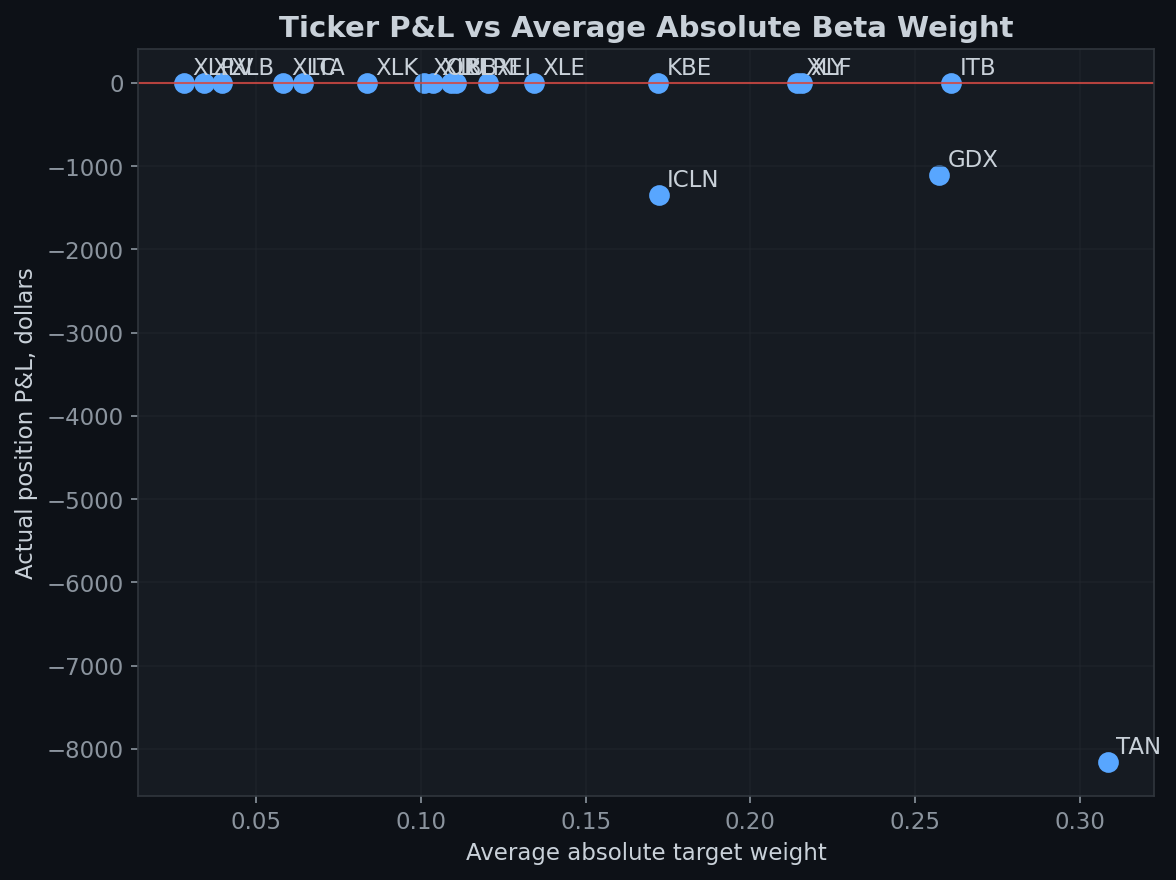

In [ ]:
if not ticker_attr.empty:
    _fig, _ax = plt.subplots(figsize=(8, 6))
    _ax.scatter(
        ticker_attr["avg_abs_weight"],
        ticker_attr["actual_pnl"],
        s=80,
        color="#58a6ff",
    )
    for _symbol, _row in ticker_attr.iterrows():
        _ax.annotate(
            _symbol,
            (_row["avg_abs_weight"], _row["actual_pnl"]),
            xytext=(4, 4),
            textcoords="offset points",
        )
    _ax.axhline(0, color="#f85149", alpha=0.7, linewidth=1)
    _ax.set_title("Ticker P&L vs Average Absolute Beta Weight")
    _ax.set_xlabel("Average absolute target weight")
    _ax.set_ylabel("Actual position P&L, dollars")
    plt.tight_layout()
    plt.show()

## Signal Decay

This realized decay view asks whether positions continue contributing after a
signal first appears. Age 0 is the first rebalance in a continuous same-side
run for a ticker; larger ages are later rebalances where the ticker remains
selected on the same side.

In [ ]:
previous_rebalance = {
    date: rebalance_dates[i - 1] for i, date in enumerate(rebalance_dates) if i > 0
}
decay = attr.sort_values(["symbol", "date"]).copy()

ages = []
run_ids = []
run_id = 0
for _symbol, _group in decay.groupby("symbol", sort=False):
    last_date = None
    last_side = None
    age = -1
    for _row in _group.itertuples():
        expected_previous = previous_rebalance.get(_row.date)
        continues = last_date == expected_previous and last_side == _row.side
        if continues:
            age += 1
        else:
            run_id += 1
            age = 0
        ages.append(age)
        run_ids.append(run_id)
        last_date = _row.date
        last_side = _row.side

decay["signal_age"] = ages
decay["signal_run_id"] = run_ids
decay["age_bucket"] = pd.cut(
    decay["signal_age"],
    bins=[-1, 0, 1, 2, 5, 10, np.inf],
    labels=["0", "1", "2", "3-5", "6-10", "11+"],
)

decay_summary = decay.groupby("age_bucket", observed=True).agg(
    pnl=("pnl_qty", "sum"),
    beta_weight_model_pnl=("pnl_weight", "sum"),
    mean_signed_return_bps=("signed_return", lambda x: x.mean() * 10000),
    median_signed_return_bps=("signed_return", lambda x: x.median() * 10000),
    hit_rate=("pnl_qty", lambda x: (x > 0).mean()),
    observations=("symbol", "size"),
    avg_abs_weight=("abs_target_weight", "mean"),
)

side_decay = decay.groupby(["age_bucket", "side"], observed=True).agg(
    pnl=("pnl_qty", "sum"),
    mean_signed_return_bps=("signed_return", lambda x: x.mean() * 10000),
    hit_rate=("pnl_qty", lambda x: (x > 0).mean()),
)

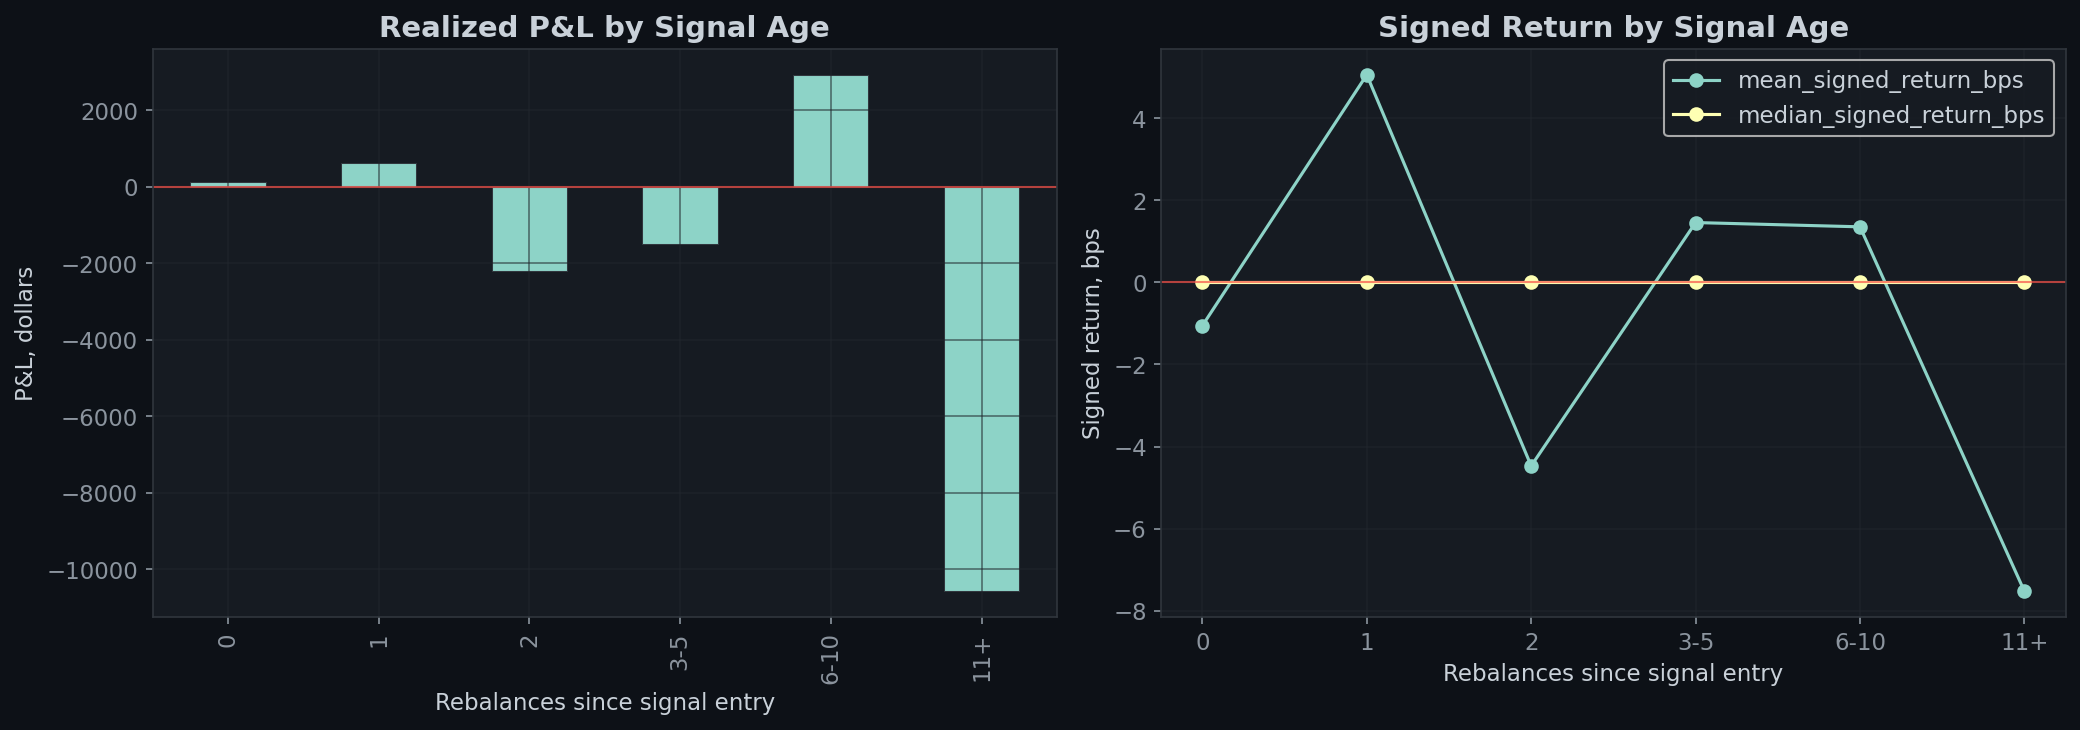

<marimo-dataframe data-initial-value='{"transforms":[]}' data-label='null' data-columns='[["pnl","number","float64"],["beta_weight_model_pnl","number","float64"],["mean_signed_return_bps","number","float64"],["median_signed_return_bps","number","float64"],["hit_rate","number","float64"],["observations","integer","int64"],["avg_abs_weight","number","float64"]]' data-dataframe-name='"decay_summary"' data-total='6' data-size-bytes='1292' data-page-size='5' data-show-download='true' data-download-json-ensure-ascii='true' data-lazy='false'>

In [ ]:
if decay_summary.empty:
    _output = mo.callout(mo.md("No signal decay rows are available."), kind="warn")
else:
    _fig, _axes = plt.subplots(1, 2, figsize=(14, 5))
    decay_summary["pnl"].plot(
        kind="bar",
        ax=_axes[0],
        title="Realized P&L by Signal Age",
        edgecolor="#30363d",
        linewidth=0.5,
    )
    _axes[0].axhline(0, color="#f85149", alpha=0.7, linewidth=1)
    _axes[0].set_xlabel("Rebalances since signal entry")
    _axes[0].set_ylabel("P&L, dollars")
    decay_summary[["mean_signed_return_bps", "median_signed_return_bps"]].plot(
        marker="o", ax=_axes[1]
    )
    _axes[1].axhline(0, color="#f85149", alpha=0.7, linewidth=1)
    _axes[1].set_title("Signed Return by Signal Age")
    _axes[1].set_xlabel("Rebalances since signal entry")
    _axes[1].set_ylabel("Signed return, bps")
    plt.tight_layout()
    plt.show()

    _output = mo.vstack(
        [
            mo.ui.dataframe(decay_summary),
            mo.ui.dataframe(side_decay["pnl"].unstack("side").fillna(0.0)),
        ]
    )
_output